---
title: "Case Study"
subtitle: "Cantilever beam"
date: today #25/04/2024
date-format: "D MMM, YYYY"
author: "Thyge Vinther Ludvigsen, s203591"
lang: en #en da  - sprog

# highlight-style: quarto_files/nord-dark-pro.theme # nord github-dark
highlight-style: nord # nord github-dark atom-one-dark
format:
  revealjs: 
    toc: true
    toc-title: "Overview"  # Customize the title of your TOC slide
    toc-depth: 1   # if 2 then it will include h2 and h3 in the TOC, if 1 then only h2
    # theme: dracula # dracula, dark, moon      Best white theme: serif, simple
    # theme: presentation_data/styles.scss
    theme: [dracula, presentation_data/styles.scss]
    slide-number: true
    incremental: false  # makes all lists incremental by default unless they have the .nonincremental class
    # chalkboard: 
    #   buttons: false
    navigation-mode: linear # this is also the default.
    preview-links: auto
    logo: presentation_data/img/DTU_logo.png
    css: presentation_data/styles.css
    footer: '[GitHub](https://github.com/Thygeminator/research-notebook)'
    # make all slides {.smaller .scrollable}
    smaller: true
    scrollable: true
    embed-resources: true
    self-contained-math: true
    echo: false
    output: false
jupyter: python3

---

<!-- include-in-header:
  text: |
    <script src="https://cdn.plot.ly/plotly-3.0.1.min.js" charset="utf-8"></script> -->

::: {.content-hidden}
# Note for building the presentation

- [github example](https://github.com/quarto-dev/quarto-web/tree/main/docs/presentations/revealjs/demo)
    - [view of the slide show](https://quarto.org/docs/presentations/revealjs/demo/#/title-slide)

- [Quarto Documentation: Presentations](https://quarto.org/docs/presentations/)
    - note: that the revealjs — reveal.js (HTML) is the best options if i want to display heavy math
:::

In [178]:
import numpy as np
import matplotlib.pyplot as plt

## Time Plan

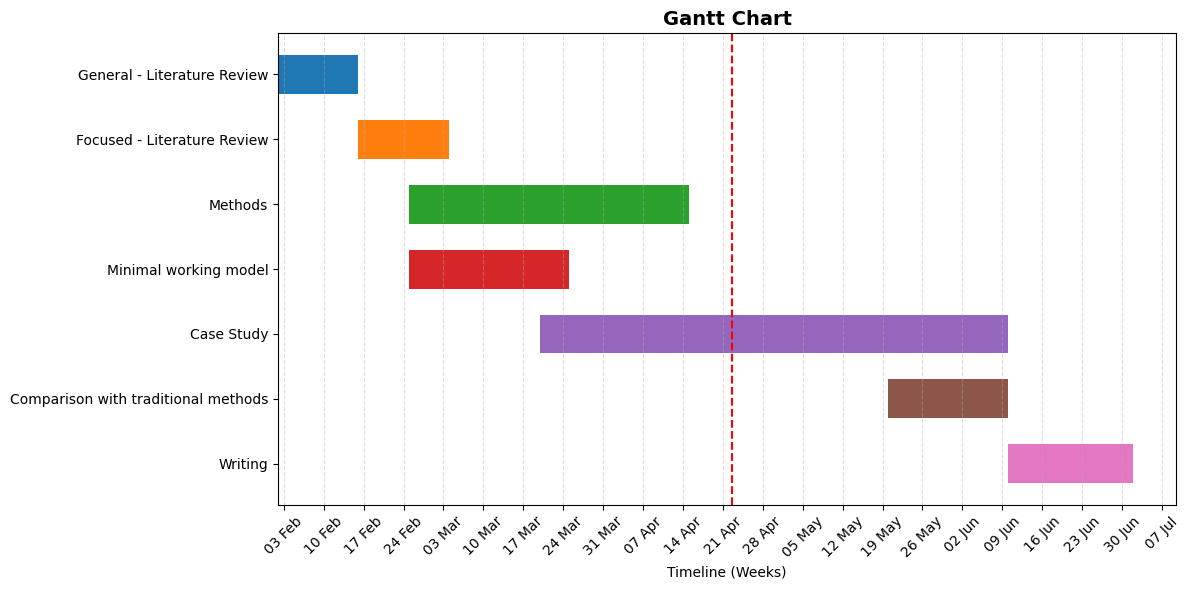

In [179]:
#| echo: false
#| output: true
from python_code.gantt_chart import create_gantt_chart

create_gantt_chart()

::: {.content-hidden}
Physics → modal parameters → features → decisions

- Implicit likelihood vs explicit/exact likelihood  (Likelihoods are approximated or implicitly defined, e.g., through simulations, rather than explicitly formulated.)
  - have statistical models for the modal parameters, and then estimate the 

Evaluation:

- Bayesian risk
- ROC curves
- Overage [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix)



Stochastic Subspace Identification (SSI)   
Value of Information (VoI)
Bayesian model updating (BMU)

prior decision analysis 
preposterior decision analysis

approximate Bayesian computation by subset simulation (ABC-SS)
Markov chain Monte Carlo (MCMC)

:::

# Introduction

## Goal of my work sins last time

::: {.fragment .fade-in}
What I test in this case study:

- Inclusion of additional features

:::

::: {.fragment .fade-in}
What is need to be done in future work:

- Optimization algorithms for sensor placement:
- Feature selection methods (e.g., PCA)
:::

::: {.notes}
- We are still using an level 1 SHM System.
:::

# New Stochastic model

## Modal parameters

Stochastic modal parameters: 


$$
(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi}) \sim p(\boldsymbol\omega, \boldsymbol\phi \mid \theta)
$$

$$
(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi}) \sim g(\theta, e) + \epsilon(\theta, e)
$$

Where: 

- $g(\theta, e)$ is the deterministic part of the model, which depends on the structural state $\theta$ and the sensor configuration $e$.
- $\epsilon(\theta, e)  = \epsilon_0(\cdot) + ... + \epsilon_n(\cdot)$



## Sensor error model


Multivariate normal distribution:

$$
\epsilon_{\text{OMA}} \sim \mathcal{N}(0, \boldsymbol\Sigma_{OMA}(e)) 
$$

Diagonal covariance matrix: ^[[$\Sigma$](https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Bivariate_case), [$\Sigma$](https://en.wikipedia.org/wiki/Covariance_matrix#Block_matrices)]

$$
\Sigma_{\text{OMA}}(e)=
\begin{bmatrix}
\Sigma_{\omega}(e) & 0 \\
0 & \Sigma_{\phi}(e)
\end{bmatrix}
$$

## Natural frequencies

Frequency covariance Matrix:
$$
\Sigma_{\omega}(e) = \operatorname{diag}\!\left(
\operatorname{Var}(\hat{\omega}_1 \mid e),
\dots,
\operatorname{Var}(\hat{\omega}_m \mid e)
\right)
$$

Error approximation for frequencies:

$$
\boxed{
\operatorname{Var}(\hat{\omega}_i \mid e)
\;\approx\;
\frac{\sigma_\varepsilon^2}
{\;\|\mathbf S(e) \odot
 \phi_i\|_2^2}
}
$$

Where:

- $\sigma_\varepsilon = CV \cdot \mu_{\omega_i}$: sensor noise, given as sensor CV (coefficient of variation) multiplied by the mean value of the natural frequencies.
- $\|\mathbf S(e) \odot \phi_i\|_2^2$: is the modal observability,
   - $\| x \|_2$ is the L2 norm of the vector $x$, so the euclidean distance.
   - $\mathbf S(e)$ is the sensor configuration vector.
   - $\phi_i$ is the mode shape vector for the $i$-th mode, which describes the deformation pattern of the structure at that mode.
   - $\odot$ denotes the element-wise (Hadamard) product, which multiplies corresponding elements of the two vectors.







In [202]:
import numpy as np

a = np.array([1, 1, 1, 0, 0, 0, 0, 0])
a = np.array([1, 1, 1, 1, 1, 1, 1, 0])
b = np.array([1, -1, 0.01, -1, 1, -1, -1, 1])

np.dot(a, b), 
# do this in np [a[0] * b[0], a[1] * b[1], a[2] * b[2], a[3] * b[3]] 
np.linalg.norm(np.multiply(a, b))

np.float64(2.4495101551126504)

In [181]:
T = 5 * 60 

T / 1, T / 0.149

(300.0, 2013.4228187919464)

## Mode shapes

Mode shape covariance matrix: ^[[\operatorname{blkdiag}](), [Block matrix](https://en.wikipedia.org/wiki/Block_matrix)]
<!-- $$
\Sigma_{\phi}(e) = \operatorname{blkdiag}\!\left(
\operatorname{Var}(\hat{\phi}_1 \mid e),
\dots,
\operatorname{Var}(\hat{\phi}_m \mid e)
\right)
$$ -->

$$
\Sigma_{\phi}(e) = \operatorname{diag}\!\left(
\operatorname{Var}(\hat{\phi}_1 \mid e),
\dots,
\operatorname{Var}(\hat{\phi}_m \mid e)
\right)
$$

Error approximation for mode shapes:
$$
\boxed{
\operatorname{Var}(\hat{\phi}_i \mid e)
\;\approx\;
\frac{ \sigma_\varepsilon^2 }
{\;\|\mathbf S(e) \odot \phi_i\|_2^{}}
}
$$

Where:

- $\sigma_\varepsilon = CV \cdot \mathbf S(e) \odot \phi_i$: sensor noise, given as sensor CV (coefficient of variation) multiplied by the mean value of the natural frequencies.
- $\|\mathbf S(e) \odot \phi_i\|_2$: is the modal observability.
   - $\| x \|_2$ is the L2 norm of the vector $x$, so the euclidean distance.
   - $\mathbf S(e)$ is the sensor configuration vector.
   - $\phi_i$ is the mode shape vector for the $i$-th mode, which describes the deformation pattern of the structure at that mode.
   - $\odot$ denotes the element-wise (Hadamard) product, which multiplies corresponding elements of the two vectors.

## Features

Feature vector:

$$
\boxed{
\mathbf y = h(\bar{\boldsymbol\phi}, \bar{\boldsymbol\omega})
}
$$

::: {.fragment .fade-in}
Where $h(\cdot)$ is an function that maps the modal parameters to the feature space.

- Natural frequencies, $\omega$
- Total Modal Assurance Criterion (TMAC)
  - $MAC(\phi_a,\phi_b)=\frac{|\phi_a^T\phi_b|^2}{(\phi_a^T\phi_a)(\phi_b^T\phi_b)}$
  - $TMAC(H_{\text{no damage}}, \bar{\boldsymbol\phi}) = \sum_{i=1}^{n} \frac{|\phi_{0,i}^T \bar{\phi}_i|^2}{(\phi_{0,i}^T \bar{\phi}_i)^2}$
- Modal Flexibility: $F = \sum_{i=1}^{n} \frac{\phi_i \phi_i^T}{\omega_i^2}$
:::

::: {.notes}
- Now do we not have features there do not lead to an explicit/exact likelihood
  - we need an Implicit likelihood or Approximate likelihood 
:::

## Problems

::: {.incremental}
- Features with nonlinear combinations of stochastic variables leads to implicit likelihoods. 
:::

# Code example - Stochastic model



## Goal of this code example

::: panel-tabset

### Goal

1. Setup an new stochastic model
2. generate modal parameters given an sensor configuration.
3. Compute the features for an given sensor configuration.

### how ?

Give:

- Modal parameters for all states, $\omega$ and $\phi$
- sensor coefficients of variation (CV)
- Sensor configuration vector, $S$
- Prior probabilities for the states, $p(\theta)$

Test: 

- Calculate the variance of the modal parameters given $S$ and CV
- Generate samples of modal parameters given $S$ and CV
- Compute the features for a given sensor configuration.

### Main code class

In [182]:
#| echo: true
#| output: true
import numpy as np
from numpy.random import multivariate_normal

class BR:
  def __init__(self, omega_all, phi_all, CV_omega, CV_phi, prior, N = 10**4, print_code = False):
    # all parameters for later use
    self.omega_all = omega_all
    self.phi_all = phi_all
    # No damage parameters
    self.omega_H0 = omega_all[0]
    self.phi_H0 = phi_all[0]
    # Damage parameters
    self.omega_H1 = omega_all[1:]
    self.phi_H1 = phi_all[1:] 
    
    # Coefficient of variation for omega and phi
    self.CV_omega = CV_omega
    self.CV_phi = CV_phi

    # number of Monte Carlo samples
    self.N = N
    
    # prior probabilities for theta
    self.prior = prior

    # print code
    self.print_code = print_code


  # def feature_vector(self, features_vector):

  #   return 

  # Statical parameters for the multivariate normal distribution 
  def covariance_matrix(self, S):
    # Sensor vector
    S = np.array(S)

    # Standard deviation
    sigma_omega = self.CV_omega * self.omega_H0 
    sigma_phi = self.CV_phi * np.ones(self.phi_H0.shape[0]) 

    # modal observability
    mo = np.array([np.linalg.norm(np.multiply(S, phi_i)) for phi_i in self.phi_H0])

    # Variance Omega
    var_omega = sigma_omega**2 / (mo**2)

    # Variance Phi
    var_phi = sigma_phi**2 / (mo**(0.5))

    # Diagonal covariance matrix
    mu = np.concatenate([self.omega_H0, self.mask_and_normalize(self.phi_H0, S).flatten()])  # mean vector
    diagonal = np.concatenate([var_omega, np.repeat(var_phi, np.sum(S, dtype=int))])
    cov = np.diag(diagonal)  # covariance matrix
    
    # save for later use
    self.mu = mu
    self.cov = cov 


  def mask_and_normalize(self,X, S):
    mask = S == 1

    # Step 1: apply mask on last axis
    filtered = X[..., mask]

    # Step 2: compute max along last axis
    max_vals = np.max(np.abs(filtered), axis=-1, keepdims=True)

    # Step 3: avoid division by zero
    max_vals[max_vals == 0] = 1

    # Step 4: normalize
    return filtered / max_vals


  def MCS_modal(self, S):
    # S is the sensor vector
    S = np.array(S)

    # get covariance matrix and mean vector
    self.covariance_matrix(S)

    # Generate all states and H labels at once: theta ~ P(theta)
    states = np.random.choice(range(len(self.prior)), size=self.N, p=self.prior)
    H_vec = (states > 0).astype(int)  # 0 if state == 0, else 1
    self.states = states
    self.H_vec = H_vec

    # generate errors for omega and phi
    # errors = np.random.multivariate_normal(mean=np.zeros(self.cov.shape[0]), cov=self.cov, size=self.N)

    # model properties 
    # lambda_star = np.random.multivariate_normal(mean=self.mu, cov=self.cov, size=self.N)
    lambda_star = np.random.multivariate_normal(mean=np.zeros(self.cov.shape[0]), cov=self.cov, size=self.N)
    lambda_star[:, :len(self.omega_H0)] += self.omega_all[states]
    lambda_star[:, len(self.omega_H0):] += self.mask_and_normalize(self.phi_all[states], S).reshape(self.N, -1)
    self.lambda_star = lambda_star

    # extract omega and phi from lambda_star
    omega_bar = lambda_star[:, :len(self.omega_H0)]
    phi_bar = lambda_star[:, len(self.omega_H0):]
    phi_bar = lambda_star[:, len(self.omega_H0):].reshape(self.N, self.phi_H0.shape[0], np.sum(S, dtype=int))
    # normize phi_bar by  by the maximum absolute value across all samples for each mode
    # normalize each mode-shape vector per sample (along the last axis)
    max_abs = np.max(np.abs(phi_bar), axis=2, keepdims=True)  # shape: (N, N_phi, 1)
    phi_bar = phi_bar / np.where(max_abs == 0, 1, max_abs)
    # phi_bar = self.mask_and_normalize(phi_bar, S)

    self.omega_bar = omega_bar
    self.phi_bar = phi_bar
    

  def MAC(self, phi1, phi2):
    # Compute the Modal Assurance Criterion (MAC) between two mode shapes
    numerator = np.abs(np.dot(phi1, phi2))**2
    denominator = np.dot(phi1, phi1) * np.dot(phi2, phi2)
    return numerator / denominator if denominator != 0 else 0

  def TMAC(self, phi_theta_1, phi_theta_2):
    N_samples = phi_theta_1.shape[0]
    TMAC_matrix = np.zeros((N_samples, N_samples))
    for i in range(N_samples):
        for j in range(N_samples):
            TMAC_matrix[i, j] = self.MAC(phi_theta_1[i], phi_theta_2[j])

    # sum of diagonal of the MAC 
    self.print2("TMAC matrix:\n", TMAC_matrix)  
    TMAC = np.sum(np.diag(TMAC_matrix)) / (N_samples)

    return TMAC
  
  # Modal Flexibility (MF)
  def MF(self, phi_vec, omega_vec):
    # Compute the Modal Flexibility (MF) for a given mode shape and natural frequency
    return sum(np.diag(np.abs(np.dot(phi_vec, phi_vec.T) / (omega_vec**2))))

  def print2(self, *args):
    if self.print_code:
        print(*args)
    

:::

## Code - Setup

<!-- here is the code for setting up the stochastic model, and generating samples of modal parameters given a sensor configuration. -->

::: {.notes}
- show mode shapes and that they are normilized

:::

In [214]:
#| echo: true
#| output: true
#| code-line-numbers: "|3-9|11-13|15-16|18-19|21-22|24-28|"
np.random.seed(32)

# frequencyes and mode shapes
omega_all = np.array([[1, 6.72223044],    # H0, theta_0
                      [1.2, 8.72223044],  # H1, theta_1
                      [1.6, 10.8]])          # H1, theta_2
phi_all = np.array([[[0.4, 0.5, 1], [-0.3, -1, .5]],   # H0, theta_0
                    [[0.2, 0.2, 1], [-0.5, -1, .5]],   # H1, theta_1
                    [[-0.1, 0.1, 1], [-0.9, -1, .5]]]) # H1, theta_2

# Coefficient of variation (CV)
CV_omega = 0.1
CV_phi = 0.2

# Prior probabilities for the states (theta)
prior = np.array([0.5, 0.4, 0.1])

# Number of Samples 
N = 10**4

# Instantiate the BR class
BRinf = BR(omega_all, phi_all, CV_omega, CV_phi, prior, N)

# Sensor configuration
S = np.array([1, 1, 1])

# Generate modal parameters given the sensor configuration
BRinf.MCS_modal(S)

"""Simple results"""
print("Sampled states (theta):", BRinf.states)
print(f"#θ_0 = {sum(BRinf.states == 0)}, fraction = {sum(BRinf.states == 0) / BRinf.N:.2f}")
print(f"#θ_1 = {sum(BRinf.states == 1)}, fraction = {sum(BRinf.states == 1) / BRinf.N:.2f}")
print(f"#θ_2 = {sum(BRinf.states == 2)}, fraction = {sum(BRinf.states == 2) / BRinf.N:.2f}")

print("\nSampled modal parameters")
print("-" * 40)
print("Frequencies:")
print(np.round(BRinf.omega_bar[0], 4))

print("\nMode shapes:")
print(np.round(BRinf.phi_bar[0], 4))

Sampled states (theta): [1 0 1 ... 1 0 1]
#θ_0 = 4915, fraction = 0.49
#θ_1 = 4071, fraction = 0.41
#θ_2 = 1014, fraction = 0.10

Sampled modal parameters
----------------------------------------
Frequencies:
[1.2598 8.996 ]

Mode shapes:
[[ 0.3939  0.1459  1.    ]
 [-0.4038 -1.      0.3347]]


In [204]:
np.dot(BRinf.phi_bar[0], BRinf.phi_bar[0].T)

array([[ 1.59293264, -0.51580473],
       [-0.51580473,  1.41738764]])

In [205]:
np.dot(BRinf.phi_bar[0][1], BRinf.phi_bar[0][1].T), BRinf.phi_bar[0][1]

(np.float64(1.4173876394361264),
 array([-0.56899897, -1.        ,  0.30598661]))

In [206]:
sum(np.diag(np.abs(np.dot(BRinf.phi_bar[0], BRinf.phi_bar[0].T) / (BRinf.omega_bar[0]**2)))), BRinf.MF(BRinf.phi_bar[0], BRinf.omega_bar[0])

(np.float64(1.71163135960581), np.float64(1.71163135960581))

## Plot - Omega

::: {.notes}
- it can esaly be seen that there are 2 damage senarios in H_1
:::

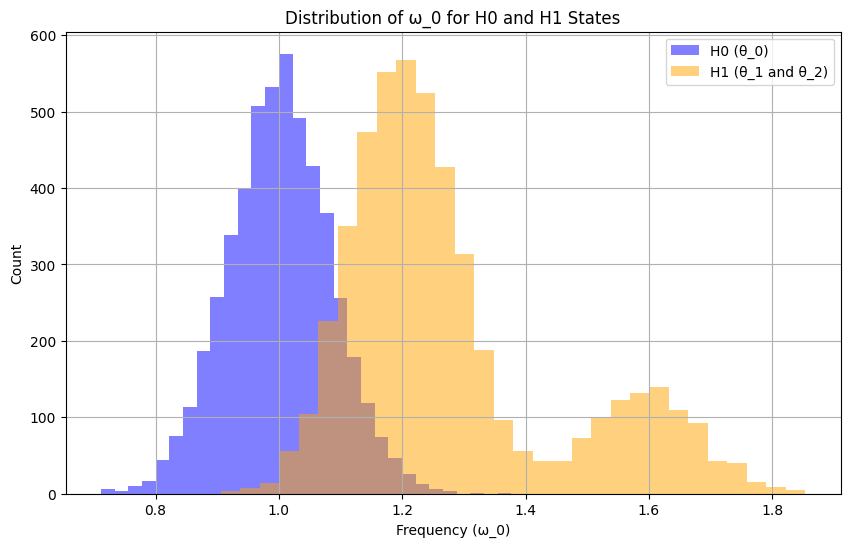

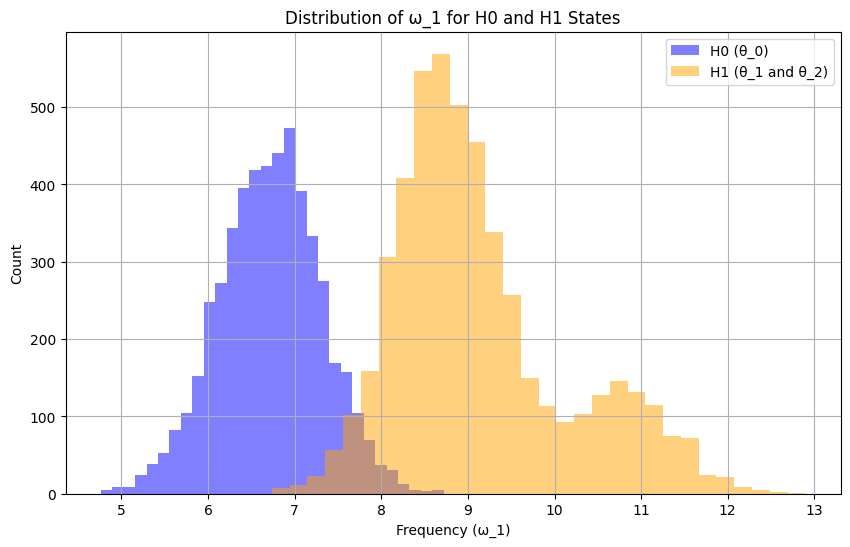

In [207]:
#| output: true

# plot omega_0 for the H0 and H1 states
plt.figure(figsize=(10, 6))
plt.hist(BRinf.omega_bar[BRinf.H_vec == 0][:, 0], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(BRinf.omega_bar[BRinf.H_vec == 1][:, 0], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('Frequency (ω_0)')
plt.ylabel('Count')
plt.title('Distribution of ω_0 for H0 and H1 States')
plt.legend()
plt.grid()
plt.show()

# plot omega_1 for the H0 and H1 states
plt.figure(figsize=(10, 6))
plt.hist(BRinf.omega_bar[BRinf.H_vec == 0][:, 1], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(BRinf.omega_bar[BRinf.H_vec == 1][:, 1], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('Frequency (ω_1)')
plt.ylabel('Count')
plt.title('Distribution of ω_1 for H0 and H1 States')
plt.legend()
plt.grid()
plt.show()

## Plot - Mode shapes 1

::: {.notes}
- see the distibution of the mode shapes, and there normilization
:::

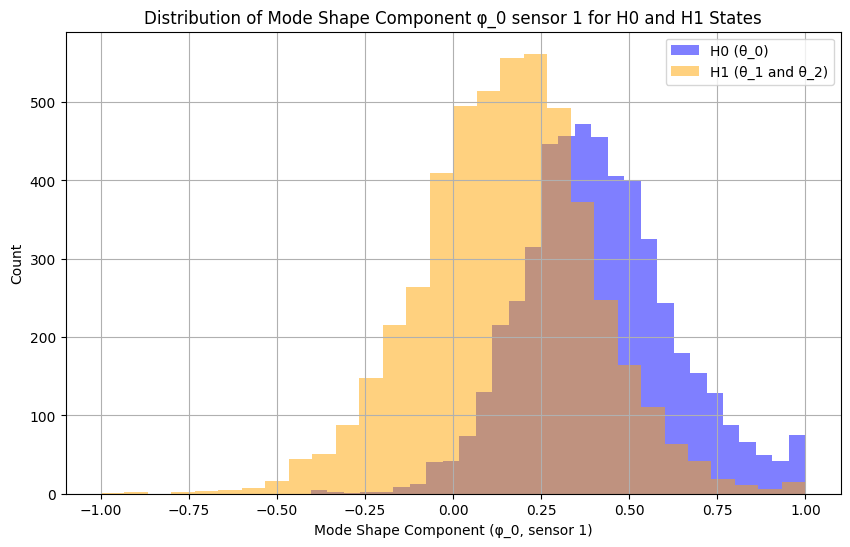

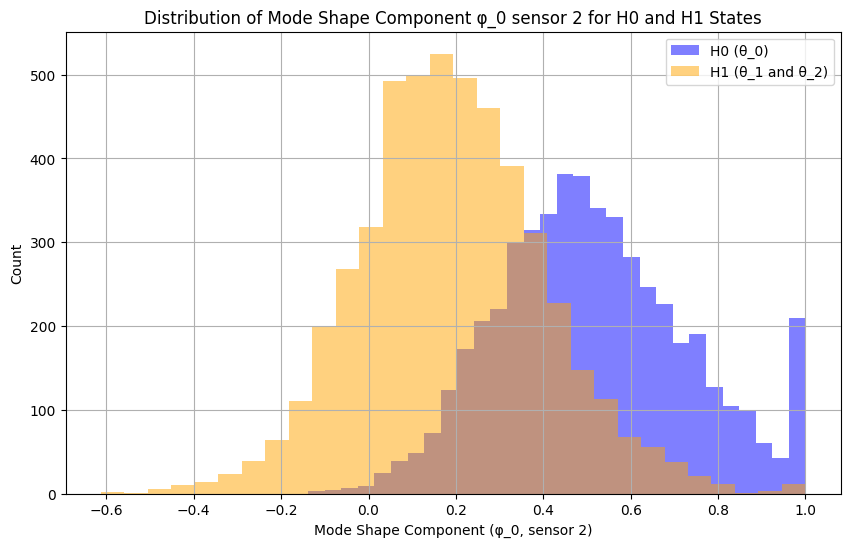

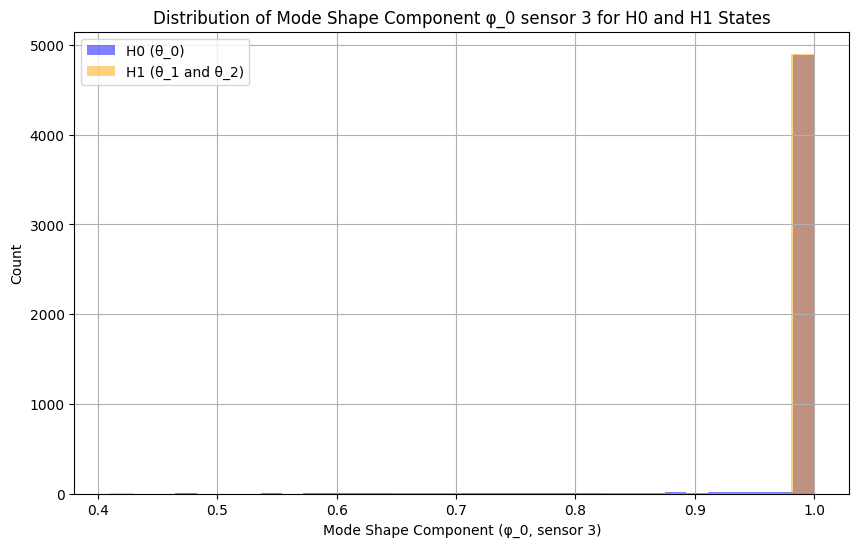

In [208]:
#| output: true

# plot mode shapes 0 for the H0 and H1 states sensor 1
plt.figure(figsize=(10, 6))
plt.hist(BRinf.phi_bar[BRinf.H_vec == 0][:, 0, 0], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(BRinf.phi_bar[BRinf.H_vec == 1][:, 0, 0], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('Mode Shape Component (φ_0, sensor 1)')
plt.ylabel('Count')
plt.title('Distribution of Mode Shape Component φ_0 sensor 1 for H0 and H1 States')
plt.legend()
plt.grid()
plt.show()

# test if the is more then one sensor
if BRinf.phi_bar.shape[2] > 1:
    # plot mode shapes 0 for the H0 and H1 states sensor 2
    plt.figure(figsize=(10, 6))
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 0][:, 0, 1], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 1][:, 0, 1], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
    plt.xlabel('Mode Shape Component (φ_0, sensor 2)')
    plt.ylabel('Count')
    plt.title('Distribution of Mode Shape Component φ_0 sensor 2 for H0 and H1 States')
    plt.legend()
    plt.grid()
    plt.show()

if BRinf.phi_bar.shape[2] > 2:
    # plot mode shapes 0 for the H0 and H1 states sensor 3
    plt.figure(figsize=(10, 6))
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 0][:, 0, 2], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 1][:, 0, 2], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
    plt.xlabel('Mode Shape Component (φ_0, sensor 3)')
    plt.ylabel('Count')
    plt.title('Distribution of Mode Shape Component φ_0 sensor 3 for H0 and H1 States')
    plt.legend()
    plt.grid()
    plt.show()



## Plot - MAC + TMAC

::: {.notes}
- all of this is an comparison of sample 1 whit undamage cass?
- I have in cluded some MAC and TMAC functions
:::

In [209]:
"MAC with mode 1 no damage and whit damage"
i = 0
print(f"MAC with mode {i+1} no damage and whit damage")
print(f"Mode shape from H0 (no damage):", BRinf.mask_and_normalize(BRinf.phi_H0, S)[0])
print(f"Mode shape first random sample:", BRinf.phi_bar[i, 0]) 

BRinf.print_code = True

mac_00 = BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[0], BRinf.phi_bar[i, 0])
print(f"\n\nMAC for mode {i+1}:", mac_00, "\n")

"TMAC with mode 1 no damage and whit damage"
tmac_00 = BRinf.TMAC(BRinf.mask_and_normalize(BRinf.phi_H0, S), BRinf.phi_bar[i])
print(f"TMAC for mode {i+1} (no damage vs damage):", tmac_00)



print(f"\nStructural state of the first random sample:", "H0 (no damage)" if BRinf.H_vec[0] == 0 else "H1 (damage)")
BRinf.print_code = False

MAC with mode 1 no damage and whit damage
Mode shape from H0 (no damage): [0.4 0.5 1. ]
Mode shape first random sample: [0.60327862 0.47852643 1.        ]


MAC for mode 1: 0.9759871572646859 

TMAC matrix:
 [[0.97598716 0.08894472]
 [0.01191993 0.92253129]]
TMAC for mode 1 (no damage vs damage): 0.9492592221290829

Structural state of the first random sample: H0 (no damage)


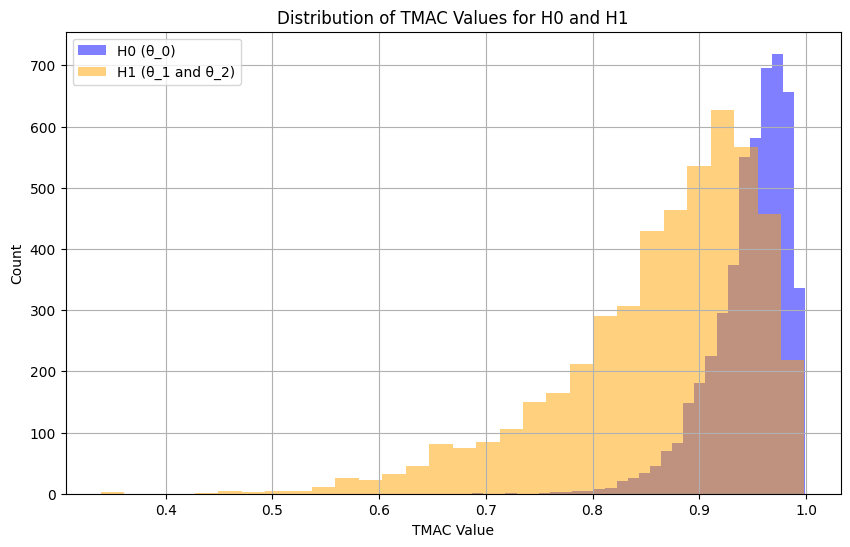

In [210]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of TMAC Values for H0 and H1')
plt.hist([ BRinf.TMAC(BRinf.mask_and_normalize(BRinf.phi_H0, S), v) for v in BRinf.phi_bar[BRinf.H_vec == 0] ], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist([ BRinf.TMAC(BRinf.mask_and_normalize(BRinf.phi_H0, S), v) for v in BRinf.phi_bar[BRinf.H_vec == 1] ], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('TMAC Value')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

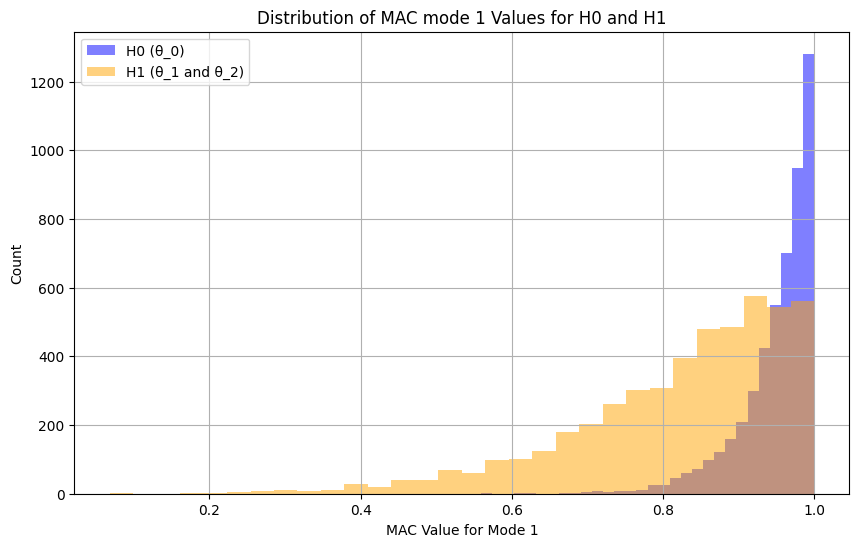

In [211]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of MAC mode 1 Values for H0 and H1')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[0], v) for v in BRinf.phi_bar[BRinf.H_vec == 0][:, 0] ], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[0], v) for v in BRinf.phi_bar[BRinf.H_vec == 1][:, 0] ], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('MAC Value for Mode 1')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()


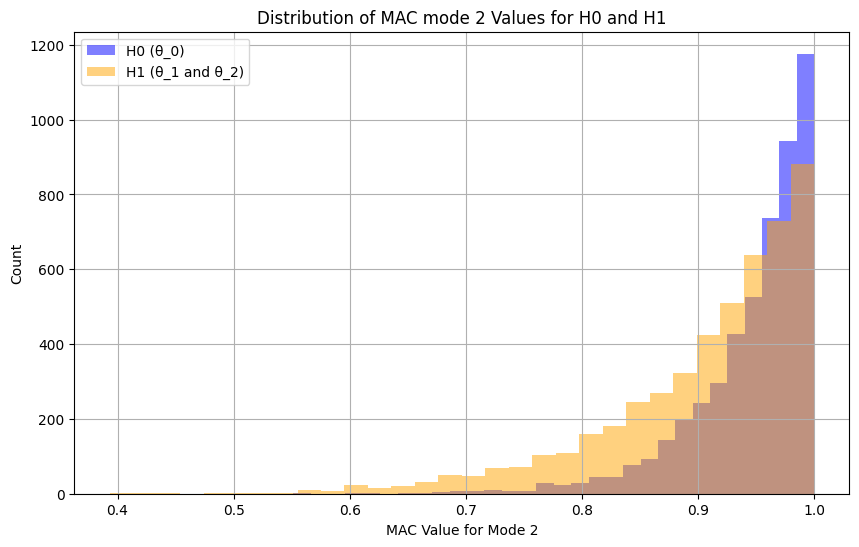

In [212]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of MAC mode 2 Values for H0 and H1')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[1], v) for v in BRinf.phi_bar[BRinf.H_vec == 0][:, 1] ], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[1], v) for v in BRinf.phi_bar[BRinf.H_vec == 1][:, 1] ], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('MAC Value for Mode 2')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

## Plot - Modal Flexibility (MF)

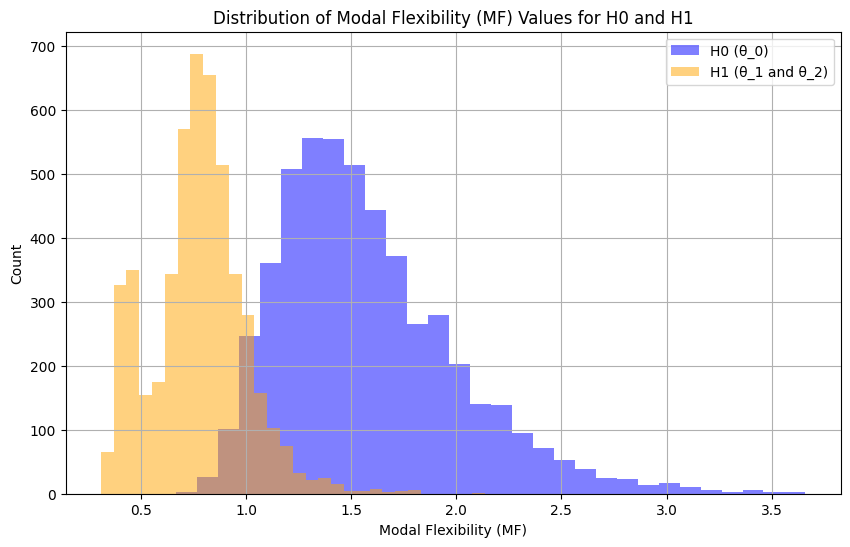

In [213]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of Modal Flexibility (MF) Values for H0 and H1')

h0_mask = BRinf.H_vec == 0
h1_mask = BRinf.H_vec == 1

mf_h0 = [BRinf.MF(phi, omega) for phi, omega in zip(BRinf.phi_bar[h0_mask], BRinf.omega_bar[h0_mask])]
mf_h1 = [BRinf.MF(phi, omega) for phi, omega in zip(BRinf.phi_bar[h1_mask], BRinf.omega_bar[h1_mask])]

plt.hist(mf_h0, bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(mf_h1, bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')

plt.xlabel('Modal Flexibility (MF)')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

# Questions

## Likelihood double use 

Workflow MCS for Bayesian risk:

0. ... 
1. for an sensor configuration $S$, calculate the staticial parameters for the likelihood function. 
2. sample structural states, $\theta$, from the prior distribution, $p(\theta)$.
3. sample modal parameters, $(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi})$, from the likelihood function, $p(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi} \mid \theta, S)$.
4. compute the likelihood of the modal properties for being in state $H_0$ or $H_1$
    - But I use the error function for the sensor configuration as if it was perfectly known?
5. ...

::: {.callout-caution title="Question ?"}
In this setup of the model, do I assume **perfect knowledge of the statistical error parameters** for a given sensor configuration when I calculate the likelihood of the modal properties for being in state $H_0$ or $H_1$?

- Is this a defensible approach, or is it problematic for the validity of the model?
:::

::: {.notes}
- What is this error called? = Ignoring uncertainty in the nuisance parameters = "underpropagation of uncertainty" or "ignoring hyperparameter uncertainty"
- Fix use an hierarchical model, where the error parameters are also treated as random variables with their own prior distributions.
:::

## likelihood: explicit to implicit

When we **introduce the stochasticity in the model parameters**, and **not in the features**, do we end up with a problem for the **likelihood function**? 

- We have nonlinear combinations of normaly distributed variables, which leads to non-normal distributions of the features
- this means that we can not use an multivariate normal distribution as likelihood function for the features, which is what we have been doing in the past.

::: {.callout-caution title="Question ?"}
What to do now? 
:::  



::: {.callout-tip title="Solution 1: Explicit likelihood"}
- Use some of the modal properties as features
- select thos whit the biggets difference between the damage and undamage state.
:::

::: {.callout-tip title="Solution 2: Implicit likelihood"}
General work flow:

- Given an sensor configuration
- Sample the modal parameters
- Compute the features for each sample
- Build an empirical distribution of the features for each state, which can be used as an implicit likelihood function for the features.  (&starf;) ($\Large \star$)
- Usse the Implicit likelihood for the features in the Bayesian decision analysis.

Idea: build an surrogate model that links variance in OMA error to likelihood of the features. (Fast computation)
:::


::: {.callout-tip title="Solution 3: No likelihood"}
Idea:  

Inttroduce a decision rule there dos not use the likelihood function, but instead directly uses the features to make decisions.

Example: 

- Train an supervised machine learning (ML) algorithm to classify the structural states based on the features.
- Use Monte Carlo simulations to estimate the risk (Bayesian risk) for this decision rule.

Problems: 

- What to use as training data for the ML algorithm?
- what algorithm to use?
    - Simpe start: use Tree-based methods se Cap 9 in [Introduction to Machine Learning and Data Mining](https://02465material.pages.compute.dtu.dk/02465public/_assets/02450Book.pdf) page 169. 

:::



::: {.notes}
- implicit likelihood: is defined through simulations, rather than explicitly formulated.
- explicit likelihood: is explicitly formulated based on a mathematical model of the data-generating process, allowing for direct computation of probabilities.



Maby relevant papper: [Non-Linear Transformations of Gaussians and Gaussian-Mixtures with implications on Estimation and Information Theory](https://arxiv.org/pdf/1111.5950)
:::

## Implicite likelihoode

::: {.callout-caution title="Question ?"}
Have you bild an implicit likelihood function befor? and do you have any tips / resources for how to do it?
:::  

::: {.callout-caution title="Problems"}
- what data to use for building the implicit likelihood?
- how to build the implicit likelihood for an vector of features? 
- Iders for building a surrogate mode there links the variance in the OMA error for an given sensor configuration to the likelihood of the features? (Fast computation)

Note: all this is dependent on the structure there is evluated.
:::  

## No likelihood

Use supervised machine learning (ML) to directly classify the structural states $H_0$ and $H_1$ based on the features.

::: {.callout-caution title="Question ?"}
- what data to use for training the ML algorithm? (&starf; &starf; &starf;)
    - Use data for difrent sensor configurations, but dont lable the configurations ?
    - set up bound for the staticial paramters for the OMA error chose chose different noise levels for the training data? 
    - generate data independent of the prior distributions? 
- Do you think that Tree-based classification methods would be a good starting point for this problem?

Note: all this is dependent on the structure there is evluated.
:::  

# Cass study

## Goal of this Cass study

::: {.incremental}
- Setup an new stochastic model
- Evaluate the Bayes risk whit the new stochastic model
:::

## Chosen Features

Modal properties: 

- x first natural frequencies
- x first mode shapes


Features: 

- x first natural frequencies
- Total Modal Assurance Criterion (TMAC)
  - $MAC(\phi_a,\phi_b)=\frac{|\phi_a^T\phi_b|^2}{(\phi_a^T\phi_a)(\phi_b^T\phi_b)}$
  - with no damage as reference
- Modal Flexibility
  - $F = \sum_{i=1}^{n} \frac{\phi_i \phi_i^T}{\omega_i^2}$




::: {.content-hidden}
# Running the document 
:::

In [ ]:
#| echo: false
#| output: false
#-- åben pdf
import os
def open_pdf(file_path):
    try:
        os.startfile(file_path)
        print("PDF-filen er åbnet.")
    except Exception as e:
        print(f"Der opstod en fejl: {e}")
def close_adobe_acrobat():
    os.system("taskkill /f /im Acrobat.exe")  # Luk Adobe Acrobat Reader
#-- hent filnaven
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
notebook_name = os.path.splitext(os.path.basename(path))[0]
#-- test count
countPDF = 0; countHTML = 0;countGitHub = 0
# countPDF = 0; countHTML = 1;countGitHub = 0
# countPDF = 0; countHTML = 1;countGitHub = 1

In [195]:
#| echo: false
#| output: false
# countPDF += 1
# if countPDF > 1: #!quarto render notebook_name.ipynb --to pdf
#   os.system(f"quarto render {notebook_name}.ipynb --to beamer")
#   #open_pdf(f"{notebook_name}.pdf")
#   os.system(f"start {notebook_name}.pdf")

In [196]:
#| echo: false
#| output: false
# quarto render P_new.ipynb --to revealjs --output P_new.html
countHTML += 1
if countHTML > 1: #!quarto render notebook_name.ipynb --to html
  os.system(f"quarto render {notebook_name}.ipynb --to revealjs --output {notebook_name}.html")
  os.system(f"start {notebook_name}.html")

In [197]:
#| echo: false 
#| output: false
# save an copy notebook_name.html in the "research-notebook" folder and rename it "index.html"ArithmeticError
countGitHub += 1
if countGitHub > 1:
  from quarto_files.git_add import git_add_and_push
  # add index.html to git and push to GitHub
  git_add_and_push(notebook_name, output_name="P_new",  type="html")
  # add Readme.md to git and push to GitHub
#   git_add_and_push("Readme", type="md")
  
